In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
rnk = pd.read_parquet('../nba_dataset/ranking.parquet')
games_detail = pd.read_parquet('../nba_dataset/games_details.parquet')
games = pd.read_csv('../nba_dataset/games.csv')
teams = pd.read_csv('../nba_dataset/teams.csv')


In [60]:
rnk.dtypes

TEAM_ID            int64
LEAGUE_ID          int64
SEASON_ID          int64
STANDINGSDATE     object
CONFERENCE        object
TEAM              object
G                  int64
W                  int64
L                  int64
W_PCT            float64
HOME_RECORD       object
ROAD_RECORD       object
RETURNTOPLAY     float64
dtype: object

In [61]:
games.dtypes

GAME_DATE_EST        object
GAME_ID               int64
GAME_STATUS_TEXT     object
HOME_TEAM_ID          int64
VISITOR_TEAM_ID       int64
SEASON                int64
TEAM_ID_home          int64
PTS_home            float64
FG_PCT_home         float64
FT_PCT_home         float64
FG3_PCT_home        float64
AST_home            float64
REB_home            float64
TEAM_ID_away          int64
PTS_away            float64
FG_PCT_away         float64
FT_PCT_away         float64
FG3_PCT_away        float64
AST_away            float64
REB_away            float64
HOME_TEAM_WINS        int64
dtype: object

In [62]:
games_detail.dtypes

GAME_ID                int64
TEAM_ID                int64
TEAM_ABBREVIATION     object
TEAM_CITY             object
PLAYER_ID              int64
PLAYER_NAME           object
NICKNAME              object
START_POSITION        object
COMMENT               object
MIN                   object
FGM                  float64
FGA                  float64
FG_PCT               float64
FG3M                 float64
FG3A                 float64
FG3_PCT              float64
FTM                  float64
FTA                  float64
FT_PCT               float64
OREB                 float64
DREB                 float64
REB                  float64
AST                  float64
STL                  float64
BLK                  float64
TO                   float64
PF                   float64
PTS                  float64
PLUS_MINUS           float64
dtype: object

In [64]:
#-------------------------------
#2022시즌만 필터링
#-------------------------------
games_2022 = games[games['SEASON'] == 2022].copy()
rnk_2022   = rnk[rnk['SEASON_ID'] == 22022].copy()


In [65]:
#-------------------------------
#games_detail → 경기×팀 단위로 만들기
#-------------------------------

gd_2022 = games_detail.merge(
    games_2022[['GAME_ID']],
    on='GAME_ID',
    how='inner'
)

team_game = (
    gd_2022
    .groupby(['GAME_ID','TEAM_ID'], as_index=False)
    .agg(
        PTS=('PTS','sum'),
        FGA=('FGA','sum'),
        FTA=('FTA','sum')
    )
)

team_game['TS_PCT'] = (
    team_game['PTS'] /
    (2 * (team_game['FGA'] + 0.44 * team_game['FTA']))
)


In [66]:
#----------------------
#games_2022에 홈/원정 TS% 붙이기
#----------------------
home_ts = team_game.rename(columns={
    'TEAM_ID':'HOME_TEAM_ID',
    'TS_PCT':'HOME_TS_PCT'
})

games_2022 = games_2022.merge(
    home_ts[['GAME_ID','HOME_TEAM_ID','HOME_TS_PCT']],
    on=['GAME_ID','HOME_TEAM_ID'],
    how='left'
)


In [67]:
away_ts = team_game.rename(columns={
    'TEAM_ID':'VISITOR_TEAM_ID',
    'TS_PCT':'AWAY_TS_PCT'
})

games_2022 = games_2022.merge(
    away_ts[['GAME_ID','VISITOR_TEAM_ID','AWAY_TS_PCT']],
    on=['GAME_ID','VISITOR_TEAM_ID'],
    how='left'
)


In [68]:
games_2022[['HOME_TS_PCT','AWAY_TS_PCT']].isna().mean()


HOME_TS_PCT    0.0
AWAY_TS_PCT    0.0
dtype: float64

In [69]:
#----------------------
#팀별 홈/원정 평균 스탯
#----------------------
home_avg = (
    games_2022.groupby('HOME_TEAM_ID')
    .agg(
        HOME_TS_PCT=('HOME_TS_PCT','mean'),
        HOME_FG_PCT=('FG_PCT_home','mean'),
        HOME_FG3_PCT=('FG3_PCT_home','mean'),
        HOME_FT_PCT=('FT_PCT_home','mean'),
        HOME_AST=('AST_home','mean'),
        HOME_REB=('REB_home','mean')
    )
    .reset_index()
    .rename(columns={'HOME_TEAM_ID':'TEAM_ID'})
)

away_avg = (
    games_2022.groupby('VISITOR_TEAM_ID')
    .agg(
        AWAY_TS_PCT=('AWAY_TS_PCT','mean'),
        AWAY_FG_PCT=('FG_PCT_away','mean'),
        AWAY_FG3_PCT=('FG3_PCT_away','mean'),
        AWAY_FT_PCT=('FT_PCT_away','mean'),
        AWAY_AST=('AST_away','mean'),
        AWAY_REB=('REB_away','mean')
    )
    .reset_index()
    .rename(columns={'VISITOR_TEAM_ID':'TEAM_ID'})
)


In [70]:
#-------------------------------
#rnk에 승률만들기
#-------------------------------

rnk_2022[['HOME_W','HOME_L']] = rnk_2022['HOME_RECORD'].str.split('-',expand=True).astype(int)
rnk_2022[['ROAD_W','ROAD_L']] = rnk_2022['ROAD_RECORD'].str.split('-',expand=True).astype(int)

rnk_2022['HOME_WIN_PCT'] = rnk_2022['HOME_W'] / (rnk_2022['HOME_W'] + rnk_2022['HOME_L'])
rnk_2022['ROAD_WIN_PCT'] = rnk_2022['ROAD_W'] / (rnk_2022['ROAD_W'] + rnk_2022['ROAD_L'])
rnk_2022['HOME_DEPENDENCY'] = rnk_2022['HOME_WIN_PCT'] - rnk_2022['ROAD_WIN_PCT']

rnk_2022_final = (
    rnk_2022.sort_values('STANDINGSDATE')
            .groupby('TEAM_ID')
            .tail(1)
)


In [71]:
#병합
df = (
    home_avg
    .merge(away_avg, on='TEAM_ID')
    .merge(
        rnk_2022_final[['TEAM_ID','TEAM','HOME_WIN_PCT','ROAD_WIN_PCT','HOME_DEPENDENCY']],
        on='TEAM_ID'
    )
)


In [72]:
top5 = df.nlargest(5,'HOME_DEPENDENCY')
bottom5 = df.nsmallest(5,'HOME_DEPENDENCY')


In [75]:
#HOME_DEPENDENCY Top5 팀
top5 = df.nlargest(5, 'HOME_DEPENDENCY').copy()
top5[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT']]


,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT
7,Golden State,0.699248,0.857143,0.157895
2,Cleveland,0.488889,0.888889,0.400000
26,Memphis,0.466667,0.866667,0.400000
5,Dallas,0.439216,0.705882,0.266667
19,Phoenix,0.420635,0.777778,0.357143


In [ ]:
#홈 vs 원정 평균 스탯 비교 그래프 (Top5)
#(A) 비교할 변수 선택
compare_cols = [
    ('TS%',  'HOME_TS_PCT',  'AWAY_TS_PCT'),
    ('FG%',  'HOME_FG_PCT',  'AWAY_FG_PCT'),
    ('3P%',  'HOME_FG3_PCT', 'AWAY_FG3_PCT'),
    ('FT%',  'HOME_FT_PCT',  'AWAY_FT_PCT'),
    ('AST',  'HOME_AST',     'AWAY_AST'),
    ('REB',  'HOME_REB',     'AWAY_REB'),
]


In [76]:
#(B) long format 변환 → 그룹바 플롯
plot_rows = []
for _, r in top5.iterrows():
    team = r['TEAM']
    for label, hcol, acol in compare_cols:
        plot_rows.append({'TEAM': team, 'Metric': label, 'Location': 'Home', 'Value': r[hcol]})
        plot_rows.append({'TEAM': team, 'Metric': label, 'Location': 'Away', 'Value': r[acol]})

plot_df = pd.DataFrame(plot_rows)


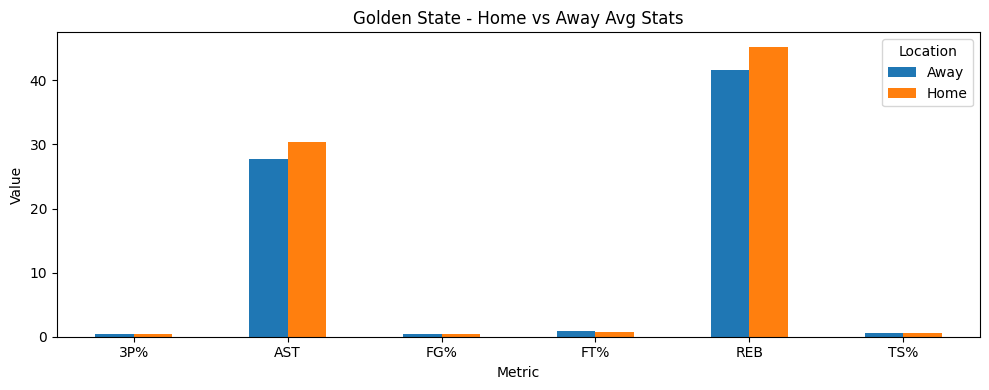

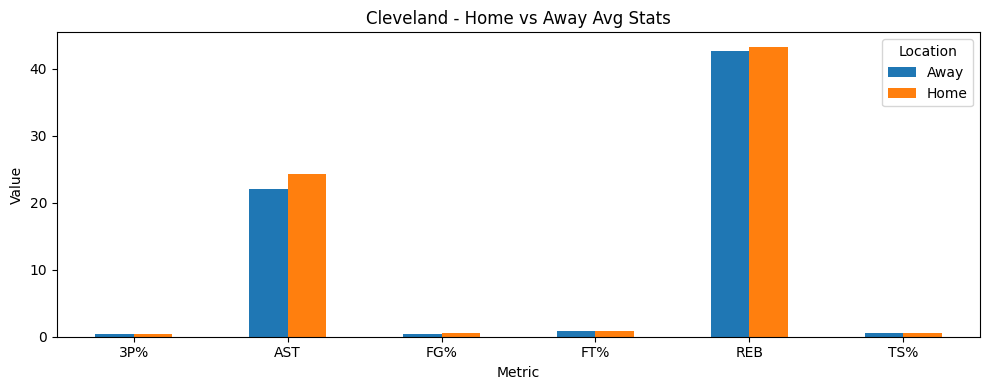

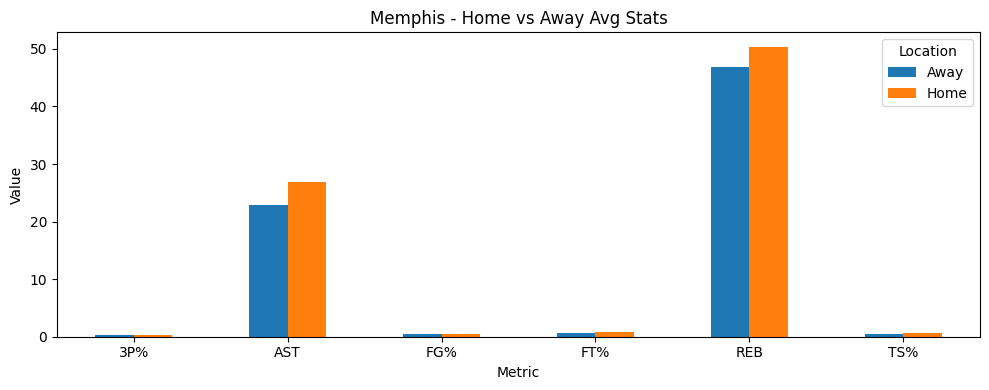

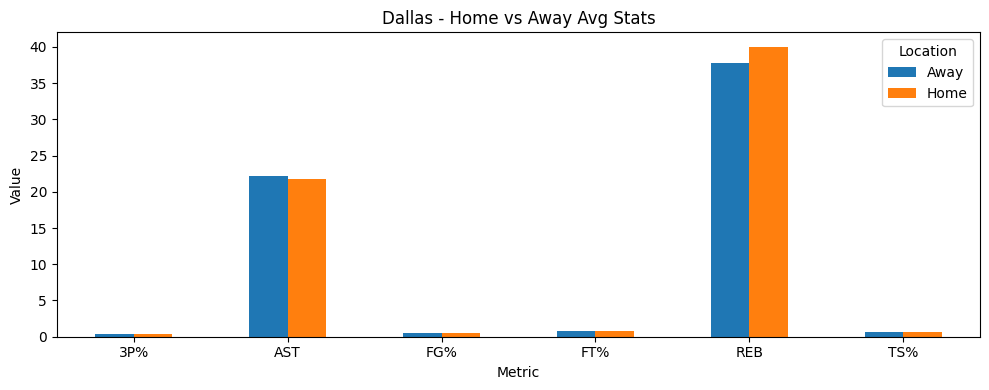

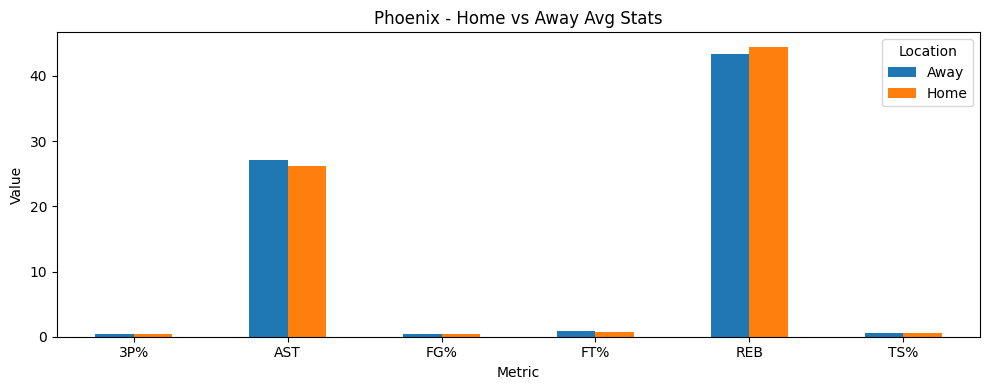

In [77]:
import matplotlib.pyplot as plt

teams = top5['TEAM'].tolist()

for t in teams:
    tmp = plot_df[plot_df['TEAM'] == t].pivot(index='Metric', columns='Location', values='Value')
    ax = tmp.plot(kind='bar', figsize=(10,4))
    plt.title(f'{t} - Home vs Away Avg Stats')
    plt.ylabel('Value')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [78]:
bottom5 = df.nsmallest(5, 'HOME_DEPENDENCY').copy()
bottom5[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT']]


,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT
15,New York,-0.125000,0.500000,0.625000
22,San Antonio,-0.063025,0.294118,0.357143
1,Boston,0.000000,0.687500,0.687500
20,Portland,0.012146,0.538462,0.526316
28,Detroit,0.027778,0.250000,0.222222


In [79]:
road_stable = bottom5[bottom5['ROAD_WIN_PCT'] >= 0.5].copy()
road_stable[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT']]


,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT
15,New York,-0.125000,0.500000,0.625000
1,Boston,0.000000,0.687500,0.687500
20,Portland,0.012146,0.538462,0.526316


In [80]:
df['TS_GAP']  = (df['HOME_TS_PCT']  - df['AWAY_TS_PCT']).abs()
df['FG_GAP']  = (df['HOME_FG_PCT']  - df['AWAY_FG_PCT']).abs()
df['AST_GAP'] = (df['HOME_AST']     - df['AWAY_AST']).abs()

stable_top = df.nsmallest(5, ['TS_GAP','FG_GAP','AST_GAP'])
stable_top[['TEAM','TS_GAP','FG_GAP','AST_GAP','HOME_WIN_PCT','ROAD_WIN_PCT']]


,TEAM,TS_GAP,FG_GAP,AST_GAP,HOME_WIN_PCT,ROAD_WIN_PCT
5,Dallas,0.000224,0.002938,0.398693,0.705882,0.266667
6,Denver,0.001320,0.003983,0.450000,0.769231,0.529412
23,Oklahoma City,0.004032,0.001043,0.551084,0.562500,0.312500
8,Houston,0.006585,0.000536,1.271242,0.400000,0.187500
24,Toronto,0.007206,0.009488,0.225146,0.625000,0.250000


In [81]:
top5[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT',
      'HOME_TS_PCT','AWAY_TS_PCT',
      'HOME_FG_PCT','AWAY_FG_PCT',
      'HOME_AST','AWAY_AST',
      'HOME_REB','AWAY_REB']]


,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT,HOME_TS_PCT,AWAY_TS_PCT,HOME_FG_PCT,AWAY_FG_PCT,HOME_AST,AWAY_AST,HOME_REB,AWAY_REB
7,Golden State,0.699248,0.857143,0.157895,0.602516,0.587412,0.484944,0.464000,30.333333,27.750000,45.222222,41.550000
2,Cleveland,0.488889,0.888889,0.400000,0.596717,0.573023,0.488550,0.466353,24.350000,22.058824,43.300000,42.705882
26,Memphis,0.466667,0.866667,0.400000,0.574075,0.546665,0.476647,0.453500,26.823529,22.888889,50.352941,46.833333
5,Dallas,0.439216,0.705882,0.266667,0.587981,0.587757,0.466056,0.463118,21.777778,22.176471,40.000000,37.823529
19,Phoenix,0.420635,0.777778,0.357143,0.584607,0.558529,0.474158,0.455562,26.263158,27.125000,44.473684,43.312500


In [82]:
road_stable[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT',
             'HOME_TS_PCT','AWAY_TS_PCT',
             'HOME_FG_PCT','AWAY_FG_PCT',
             'HOME_AST','AWAY_AST',
             'HOME_REB','AWAY_REB']]


,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT,HOME_TS_PCT,AWAY_TS_PCT,HOME_FG_PCT,AWAY_FG_PCT,HOME_AST,AWAY_AST,HOME_REB,AWAY_REB
15,New York,-0.125000,0.500000,0.625000,0.573580,0.545984,0.471421,0.437647,24.000000,22.823529,47.894737,47.176471
1,Boston,0.000000,0.687500,0.687500,0.628167,0.589932,0.496833,0.459333,28.166667,25.444444,43.777778,44.888889
20,Portland,0.012146,0.538462,0.526316,0.600025,0.573868,0.479000,0.464409,24.571429,22.954545,43.285714,41.954545


In [83]:
bottom5[['TEAM','HOME_DEPENDENCY','HOME_WIN_PCT','ROAD_WIN_PCT',
             'HOME_TS_PCT','AWAY_TS_PCT',
             'HOME_FG_PCT','AWAY_FG_PCT',
             'HOME_AST','AWAY_AST',
             'HOME_REB','AWAY_REB']]

,TEAM,HOME_DEPENDENCY,HOME_WIN_PCT,ROAD_WIN_PCT,HOME_TS_PCT,AWAY_TS_PCT,HOME_FG_PCT,AWAY_FG_PCT,HOME_AST,AWAY_AST,HOME_REB,AWAY_REB
15,New York,-0.125000,0.500000,0.625000,0.573580,0.545984,0.471421,0.437647,24.000000,22.823529,47.894737,47.176471
22,San Antonio,-0.063025,0.294118,0.357143,0.547962,0.561142,0.456550,0.468875,26.350000,27.375000,43.700000,42.562500
1,Boston,0.000000,0.687500,0.687500,0.628167,0.589932,0.496833,0.459333,28.166667,25.444444,43.777778,44.888889
20,Portland,0.012146,0.538462,0.526316,0.600025,0.573868,0.479000,0.464409,24.571429,22.954545,43.285714,41.954545
28,Detroit,0.027778,0.250000,0.222222,0.561862,0.545744,0.450889,0.436800,23.111111,21.000000,43.055556,43.500000


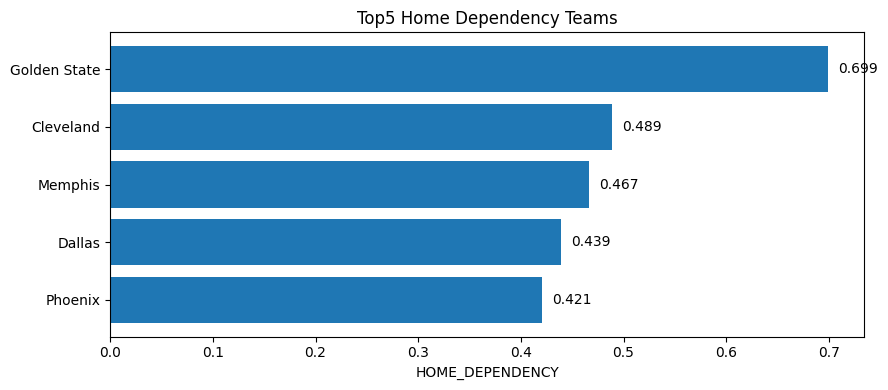

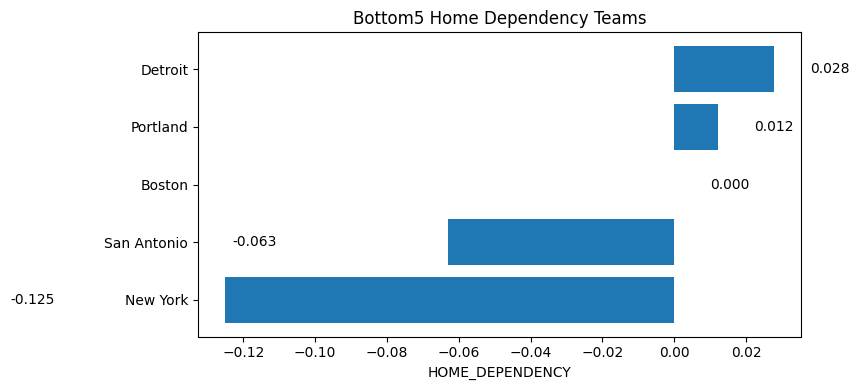

In [104]:
import matplotlib.pyplot as plt

top5_plot = top5.sort_values('HOME_DEPENDENCY', ascending=True)
bottom5_plot = bottom5.sort_values('HOME_DEPENDENCY', ascending=True)

fig, ax = plt.subplots(figsize=(9,4))
ax.barh(top5_plot['TEAM'], top5_plot['HOME_DEPENDENCY'])
ax.set_title("Top5 Home Dependency Teams")
ax.set_xlabel("HOME_DEPENDENCY")

for i, v in enumerate(top5_plot['HOME_DEPENDENCY']):
    ax.text(v + 0.01, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.barh(bottom5_plot['TEAM'], bottom5_plot['HOME_DEPENDENCY'])
ax.set_title("Bottom5 Home Dependency Teams")
ax.set_xlabel("HOME_DEPENDENCY")

for i, v in enumerate(bottom5_plot['HOME_DEPENDENCY']):
    ax.text(v + 0.01 if v>=0 else v - 0.06, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()


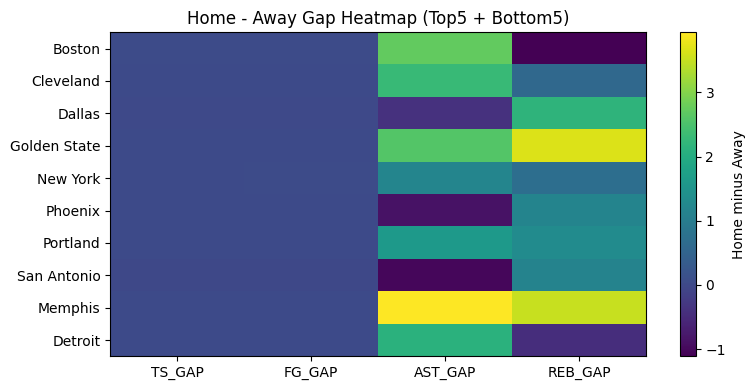

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

teams_10 = pd.concat([top5[['TEAM']], bottom5[['TEAM']]])['TEAM'].tolist()
temp = df[df['TEAM'].isin(teams_10)].copy()

temp['TS_GAP']  = temp['HOME_TS_PCT']  - temp['AWAY_TS_PCT']
temp['FG_GAP']  = temp['HOME_FG_PCT']  - temp['AWAY_FG_PCT']
temp['AST_GAP'] = temp['HOME_AST']     - temp['AWAY_AST']
temp['REB_GAP'] = temp['HOME_REB']     - temp['AWAY_REB']

heat = temp.set_index('TEAM')[['TS_GAP','FG_GAP','AST_GAP','REB_GAP']]

plt.figure(figsize=(8,4))
plt.imshow(heat.values, aspect='auto')
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), heat.columns)
plt.title("Home - Away Gap Heatmap (Top5 + Bottom5)")
plt.colorbar(label="Home minus Away")
plt.tight_layout()
plt.show()


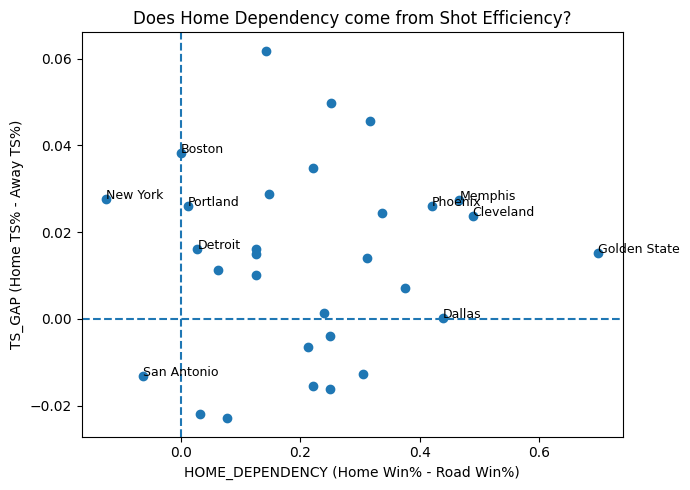

In [105]:
import matplotlib.pyplot as plt

df2 = df.copy()
df2['TS_GAP'] = df2['HOME_TS_PCT'] - df2['AWAY_TS_PCT']

plt.figure(figsize=(7,5))
plt.scatter(df2['HOME_DEPENDENCY'], df2['TS_GAP'])

for _, r in df2.iterrows():
    if r['TEAM'] in top5['TEAM'].tolist() + bottom5['TEAM'].tolist():
        plt.text(r['HOME_DEPENDENCY'], r['TS_GAP'], r['TEAM'], fontsize=9)

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("HOME_DEPENDENCY (Home Win% - Road Win%)")
plt.ylabel("TS_GAP (Home TS% - Away TS%)")
plt.title("Does Home Dependency come from Shot Efficiency?")
plt.tight_layout()
plt.show()


In [108]:
#멀티시즌
seasons = [2020, 2021, 2022, 2023]
games_ms = games[games['SEASON'].isin(seasons)].copy()
rnk_ms   = rnk[rnk['SEASON_ID'].isin([22020,22021,22022,22023])].copy()


In [109]:
home_stats = games_ms.groupby(['SEASON','HOME_TEAM_ID']).agg({
    'FG_PCT_home':'mean',
    'FG3_PCT_home':'mean',
    'AST_home':'mean',
    'REB_home':'mean'
}).reset_index()

away_stats = games_ms.groupby(['SEASON','VISITOR_TEAM_ID']).agg({
    'FG_PCT_away':'mean',
    'FG3_PCT_away':'mean',
    'AST_away':'mean',
    'REB_away':'mean'
}).reset_index()

home_stats.columns = ['SEASON','TEAM_ID','HOME_FG_PCT','HOME_FG3_PCT','HOME_AST','HOME_REB']
away_stats.columns = ['SEASON','TEAM_ID','AWAY_FG_PCT','AWAY_FG3_PCT','AWAY_AST','AWAY_REB']


In [112]:
rnk_ms = rnk_ms.copy()
rnk_ms["SEASON"] = rnk_ms["SEASON_ID"] - 20000   # 22022 -> 2022


In [111]:
rnk_ms.columns


Index(['TEAM_ID', 'LEAGUE_ID', 'SEASON_ID', 'STANDINGSDATE', 'CONFERENCE',
       'TEAM', 'G', 'W', 'L', 'W_PCT', 'HOME_RECORD', 'ROAD_RECORD',
       'RETURNTOPLAY'],
      dtype='object')

In [113]:
import pandas as pd
import numpy as np

def record_to_pct(s):
    if pd.isna(s):
        return np.nan
    w, l = s.split("-")
    w, l = int(w), int(l)
    return w / (w + l) if (w + l) > 0 else np.nan


In [114]:
rnk_ms["HOME_WIN_PCT"] = rnk_ms["HOME_RECORD"].apply(record_to_pct)
rnk_ms["ROAD_WIN_PCT"] = rnk_ms["ROAD_RECORD"].apply(record_to_pct)

rnk_ms["HOME_DEPENDENCY"] = rnk_ms["HOME_WIN_PCT"] - rnk_ms["ROAD_WIN_PCT"]


In [115]:
seasons = [2020, 2021, 2022, 2023]
games_ms = games[games["SEASON"].isin(seasons)].copy()

home_stats = games_ms.groupby(["SEASON","HOME_TEAM_ID"]).agg({
    "FG_PCT_home":"mean",
    "FG3_PCT_home":"mean",
    "AST_home":"mean",
    "REB_home":"mean",
}).reset_index()

away_stats = games_ms.groupby(["SEASON","VISITOR_TEAM_ID"]).agg({
    "FG_PCT_away":"mean",
    "FG3_PCT_away":"mean",
    "AST_away":"mean",
    "REB_away":"mean",
}).reset_index()

home_stats.columns = ["SEASON","TEAM_ID","HOME_FG_PCT","HOME_FG3_PCT","HOME_AST","HOME_REB"]
away_stats.columns = ["SEASON","TEAM_ID","AWAY_FG_PCT","AWAY_FG3_PCT","AWAY_AST","AWAY_REB"]


In [116]:
season_team = (
    rnk_ms[["SEASON","TEAM_ID","TEAM","HOME_DEPENDENCY","HOME_WIN_PCT","ROAD_WIN_PCT"]]
    .merge(home_stats, on=["SEASON","TEAM_ID"], how="left")
    .merge(away_stats, on=["SEASON","TEAM_ID"], how="left")
)


In [117]:
multi_team = season_team.groupby("TEAM").agg({
    "HOME_DEPENDENCY":"mean",
    "HOME_WIN_PCT":"mean",
    "ROAD_WIN_PCT":"mean",
    "HOME_FG_PCT":"mean",
    "AWAY_FG_PCT":"mean",
    "HOME_FG3_PCT":"mean",
    "AWAY_FG3_PCT":"mean",
    "HOME_AST":"mean",
    "AWAY_AST":"mean",
    "HOME_REB":"mean",
    "AWAY_REB":"mean",
}).reset_index()

top5_multi = multi_team.sort_values("HOME_DEPENDENCY", ascending=False).head(5)
bottom5_multi = multi_team.sort_values("HOME_DEPENDENCY", ascending=True).head(5)

top5_multi, bottom5_multi


(            TEAM  HOME_DEPENDENCY  HOME_WIN_PCT  ROAD_WIN_PCT  HOME_FG_PCT  \
 9   Golden State         0.263551      0.743328      0.476867     0.480503   
 0        Atlanta         0.214776      0.639143      0.425289     0.474664   
 28          Utah         0.173365      0.764285      0.591332     0.477249   
 15         Miami         0.159900      0.647033      0.489590     0.468615   
 8        Detroit         0.148307      0.330140      0.180534     0.441120   
 
     AWAY_FG_PCT  HOME_FG3_PCT  AWAY_FG3_PCT   HOME_AST   AWAY_AST   HOME_REB  \
 9      0.457036      0.378769      0.359523  28.674107  26.139134  44.984542   
 0      0.457213      0.374820      0.354675  24.860599  22.947396  45.281253   
 28     0.459598      0.373379      0.366561  23.531342  22.253102  47.416550   
 15     0.457184      0.365070      0.356256  25.327125  25.204687  42.268014   
 8      0.440436      0.334787      0.338306  23.179564  23.833028  43.306477   
 
      AWAY_REB  
 9   43.565684  
 0

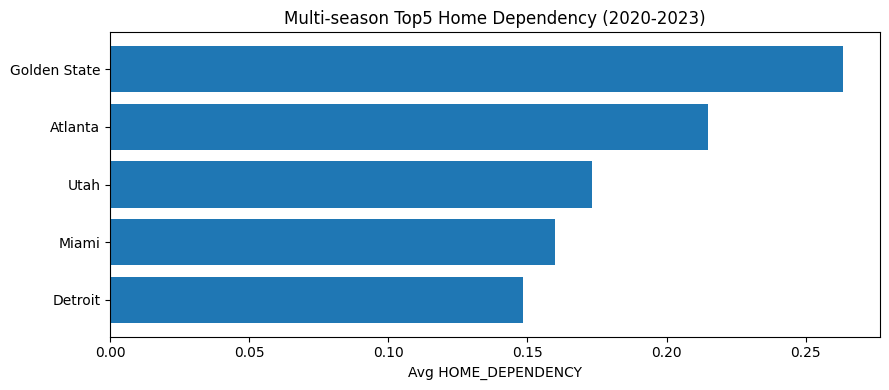

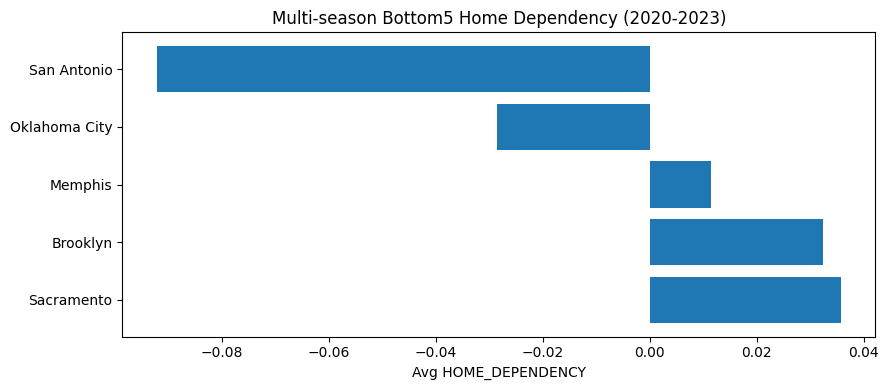

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.barh(top5_multi["TEAM"], top5_multi["HOME_DEPENDENCY"])
plt.title("Multi-season Top5 Home Dependency (2020-2023)")
plt.xlabel("Avg HOME_DEPENDENCY")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.barh(bottom5_multi["TEAM"], bottom5_multi["HOME_DEPENDENCY"])
plt.title("Multi-season Bottom5 Home Dependency (2020-2023)")
plt.xlabel("Avg HOME_DEPENDENCY")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [119]:
#홈에서 더 잘 넣기 때문에 홈 의존도가 커지는가
multi_team['FG_GAP'] = (
    multi_team['HOME_FG_PCT'] - multi_team['AWAY_FG_PCT']
)


In [120]:
corr = multi_team['HOME_DEPENDENCY'].corr(multi_team['FG_GAP'])
corr


np.float64(0.2579469942244106)